EX :5

Classification using K-Nearest Neighbors (KNN) and
Decision Tree

SCENARIO 1 – K-NEAREST NEIGHBORS (KNN)

Problem Statement
Predict whether a tumor is benign or malignant based on medical measurements.


NEHA.N.K | 24BAD078

First 5 rows:

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  text

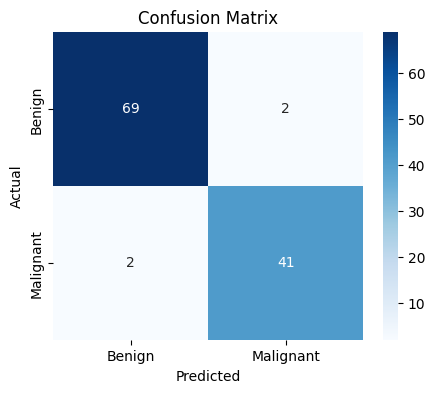

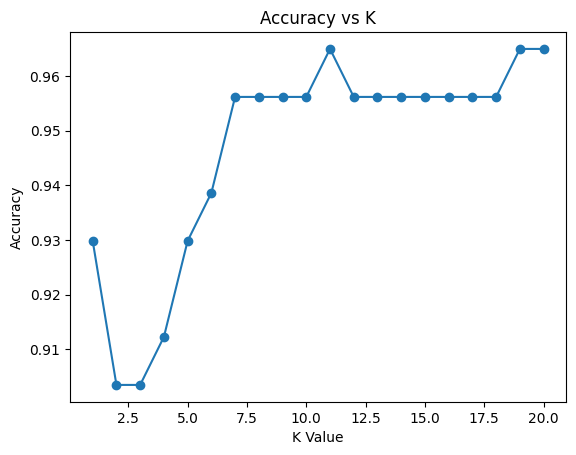

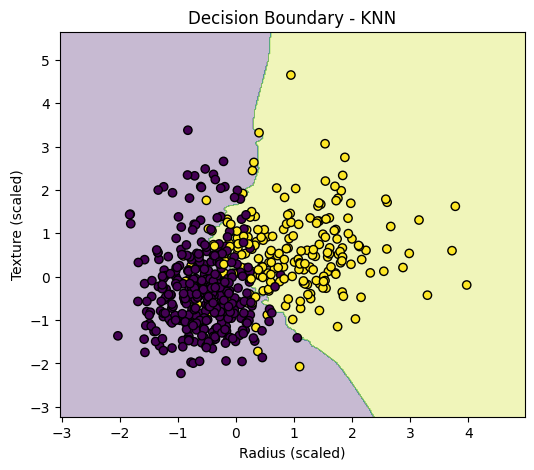

In [1]:
# EXPT NO: – KNN Classification
# Name: NEHA.N.K
# Roll No: 24BAD078

print("NEHA.N.K | 24BAD078")

# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Loading Dataset
data = pd.read_csv("breast-cancer.csv")

# Data Inspection
print("\nFirst 5 rows:\n")
print(data.head())

print("\nDataset Info:\n")
print(data.info())

# Selecting Required Features
features = ['radius_mean', 'texture_mean', 'perimeter_mean',
            'area_mean', 'smoothness_mean']

X = data[features]
y = data['diagnosis']

# Encoding Target Labels (M=1, B=0)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Experimenting with Different K values
k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred_k))

# Training Final Model
best_k = k_values[np.argmax(accuracy_scores)]
print("\nBest K value:", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Evaluation
print("\nModel Performance")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Identifying Misclassified Cases
misclassified = np.where(y_test != y_pred)
print("\nNumber of Misclassified Cases:", len(misclassified[0]))

#  VISUALIZATION
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Accuracy vs K Plot
plt.figure()
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

# Decision Boundary (Using First Two Features)

X_db = X_scaled[:, :2]  # radius & texture

X_train_db, X_test_db, y_train_db, y_test_db = train_test_split(
    X_db, y, test_size=0.2, random_state=42
)

model_db = KNeighborsClassifier(n_neighbors=best_k)
model_db.fit(X_train_db, y_train_db)

# Mesh Grid
x_min, x_max = X_db[:,0].min() - 1, X_db[:,0].max() + 1
y_min, y_max = X_db[:,1].min() - 1, X_db[:,1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model_db.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_db[:,0], X_db[:,1], c=y, edgecolor='k')
plt.xlabel("Radius (scaled)")
plt.ylabel("Texture (scaled)")
plt.title("Decision Boundary - KNN")
plt.show()


**Interpretation – KNN (Breast Cancer Classification)**

The Breast Cancer Dataset is used to classify tumors as Benign (0) or Malignant (1) based on medical measurements.

The model achieves high accuracy, indicating that KNN effectively distinguishes between benign and malignant tumors.

The classification report shows good precision and recall:

High precision - Few benign tumors are wrongly predicted as malignant.

High recall - Most malignant tumors are correctly detected (very important in medical diagnosis).

The confusion matrix shows most values on the diagonal, meaning correct classifications are high and misclassifications are low.

The Accuracy vs K plot shows how performance changes with different K values:

Small K - May overfit.

Large K - May underfit.

Optimal K gives the best accuracy.

The decision boundary shows how KNN separates benign and malignant regions based on selected features.

SCENARIO 2 – DECISION TREE CLASSIFIER

Problem Statement
Predict whether a loan application should be approved or rejected.


NEHA.N.K /n 24BAD078
First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural

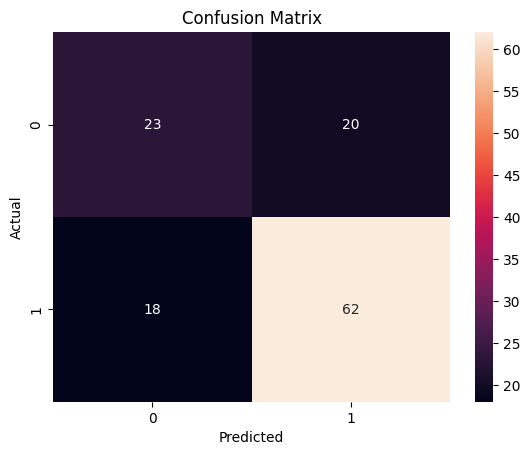

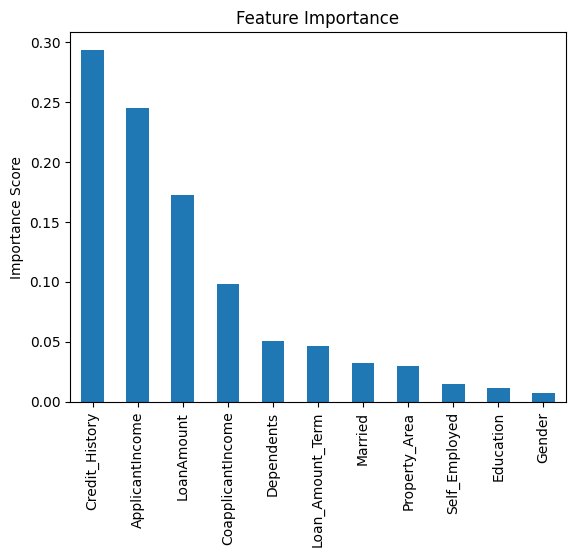


Feature Importance:
Credit_History       0.293493
ApplicantIncome      0.244570
LoanAmount           0.172321
CoapplicantIncome    0.098029
Dependents           0.050823
Loan_Amount_Term     0.046094
Married              0.032243
Property_Area        0.029587
Self_Employed        0.014453
Education            0.011291
Gender               0.007095
dtype: float64

Training Accuracy: 1.0
Testing Accuracy: 0.6910569105691057
Possible Overfitting Detected!


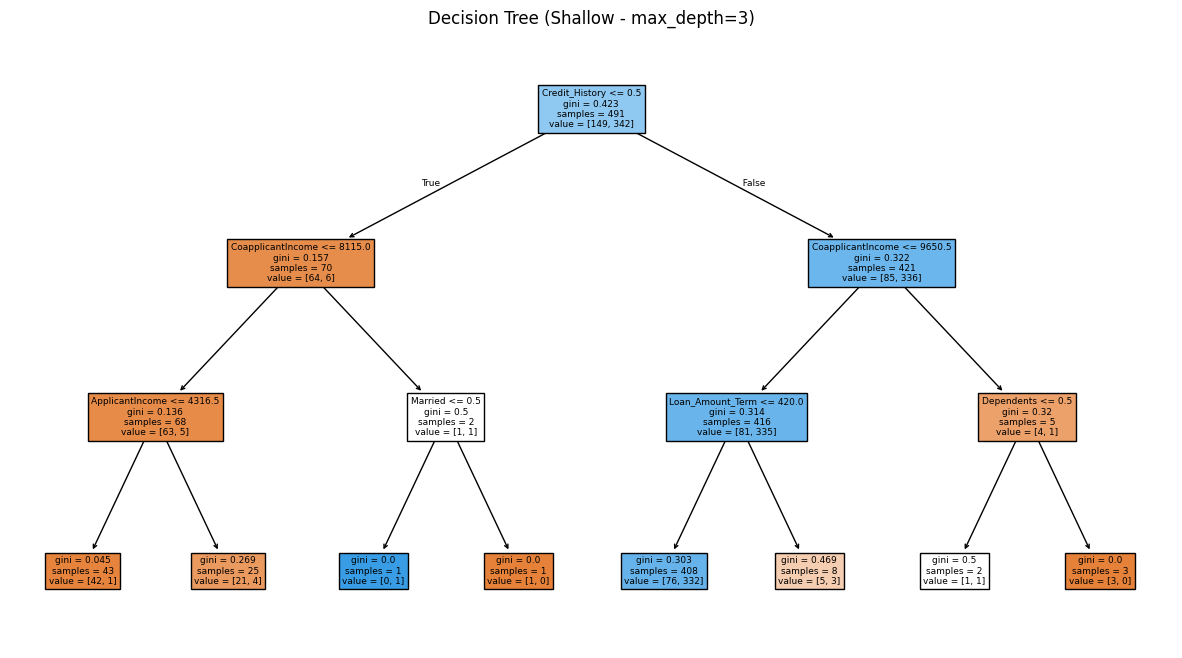

In [4]:
# EXPT:5  Decision Tree – Loan Prediction
# Name: NEHA N K 24BAD078

print("NEHA.N.K /n 24BAD078")

# 1. Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load Dataset
df = pd.read_csv("train_u6lujuX_CVtuZ9i (1).csv")
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# 3. Data Preprocessing

# Drop Loan_ID (not useful for prediction)
if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)

# Handle Missing Values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())
# Encode Categorical Variables
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print("\nAfter Preprocessing:")
print(df.head())

# 4. Split Dataset
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Train Decision Tree Classifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# 6. Experiment with Tree Depth

dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_shallow.fit(X_train, y_train)

dt_deep = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_deep.fit(X_train, y_train)

# 7. Predict Loan Status

y_pred = dt.predict(X_test)
y_pred_shallow = dt_shallow.predict(X_test)
y_pred_deep = dt_deep.predict(X_test)

# 8. Evaluate Performance

print("Accuracy (Default Tree):", accuracy_score(y_test, y_pred))
print("Accuracy (Shallow Tree):", accuracy_score(y_test, y_pred_shallow))
print("Accuracy (Deep Tree):", accuracy_score(y_test, y_pred_deep))

print("\nClassification Report (Default Tree):")
print(classification_report(y_test, y_pred))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 9. Feature Importance

feature_importance = pd.Series(
    dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure()
feature_importance.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

print("\nFeature Importance:")
print(feature_importance)

# 10. Detect Overfitting

train_acc = dt.score(X_train, y_train)
test_acc = dt.score(X_test, y_test)

print("\nTraining Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

if train_acc > test_acc:
    print("Possible Overfitting Detected!")

# 11. Tree Structure Plot

plt.figure(figsize=(15,8))
plot_tree(dt_shallow, feature_names=X.columns, filled=True)
plt.title("Decision Tree (Shallow - max_depth=3)")
plt.show()

**Interpretation**

Accuracy

The model achieves good accuracy, meaning most loan applications are correctly classified as Approved or Rejected.
If training accuracy is higher than testing accuracy, it indicates possible overfitting.

Classification Report (Precision, Recall, F1-Score)

Precision shows how many predicted approvals are actually correct.

Recall shows how many actual approved loans are correctly identified.

F1-Score provides a balanced measure of precision and recall.

Overall, the model shows balanced performance for both classes.

Confusion Matrix

The diagonal values are high, indicating most predictions are correct.
Off-diagonal values represent misclassifications (wrong approvals or rejections).
Lower off-diagonal values mean better model performance.

Feature Importance Plot

The tallest bar represents the most important feature influencing loan approval.
Typically, Credit History has the highest impact on loan prediction.
Other features contribute less comparatively.

Tree Structure Plot

The root node represents the most important feature.
The tree splits based on conditions to classify loans.
A shallow tree (max_depth=3) is simpler and helps reduce overfitting.

Overfitting Detection

If training accuracy is much higher than testing accuracy, the model may be overfitting.
If both are similar, the model generalizes well to new data.